# Transformer模型情感分析评估

本笔记本使用预训练的Transformer模型(BERT)对测试数据集进行情感分析,并与人工标注结果进行对比评估。

## 1. 环境准备与依赖安装

In [ ]:
!pip install transformers torch tqdm scikit-learn matplotlib seaborn cryptography ipywidgets -q

## 2. 导入库并检查CUDA环境

In [1]:
import sys
import os
sys.path.append('..')

import asyncio
from datetime import datetime
from typing import List, Tuple

import aiomysql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# 导入数据库配置
from config import db_config

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 检查CUDA
print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA是否可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA版本: {torch.version.cuda}")
    print(f"GPU设备: {torch.cuda.get_device_name(0)}")
    print(f"GPU内存: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

PyTorch版本: 2.5.1
CUDA是否可用: True
CUDA版本: 11.8
GPU设备: NVIDIA GeForce RTX 4060 Laptop GPU
GPU内存: 8.00 GB


In [4]:
# 数据库配置
TEST_DB_NAME = "nlp_test_dataset"

# 模型配置
MODEL_NAME = "bert-base-chinese"  # 可修改为其他模型
# MODEL_NAME = "hfl/chinese-roberta-wwm-ext"  # 推荐使用
# MODEL_NAME = "hfl/chinese-bert-wwm-ext"

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MAX_LENGTH = 512  # BERT最大输入长度
BATCH_SIZE = 16   # 批处理大小(根据显存调整)

print(f"模型: {MODEL_NAME}")
print(f"设备: {DEVICE}")
print(f"批大小: {BATCH_SIZE}")

模型: bert-base-chinese
设备: cuda
批大小: 16


## 3. 数据库连接与数据加载

In [5]:
async def get_mysql_connection():
    """创建MySQL连接"""
    return await aiomysql.connect(
        host=db_config.MYSQL_DB_HOST,
        port=db_config.MYSQL_DB_PORT,
        user=db_config.MYSQL_DB_USER,
        password=db_config.MYSQL_DB_PWD,
        db=TEST_DB_NAME,
        charset='utf8mb4',
        autocommit=True
    )

async def load_annotated_data():
    """加载已标注的测试数据"""
    conn = await get_mysql_connection()
    try:
        async with conn.cursor(aiomysql.DictCursor) as cursor:
            # 加载笔记数据
            await cursor.execute("""
                SELECT id, platform, title, content, 
                       manual_sentiment_label, manual_sentiment_score
                FROM test_notes 
                WHERE is_annotated = TRUE
                ORDER BY id
            """)
            notes = await cursor.fetchall()
            
            # 加载评论数据
            await cursor.execute("""
                SELECT id, platform, content,
                       manual_sentiment_label, manual_sentiment_score
                FROM test_comments 
                WHERE is_annotated = TRUE
                ORDER BY id
            """)
            comments = await cursor.fetchall()
            
            return notes, comments
    finally:
        conn.close()

# 加载数据
notes_data, comments_data = await load_annotated_data()

print(f"已加载笔记数据: {len(notes_data)} 条")
print(f"已加载评论数据: {len(comments_data)} 条")

if len(notes_data) == 0 and len(comments_data) == 0:
    print("\n⚠️ 警告: 没有已标注的数据!")
    print("请先使用以下SQL进行人工标注:")
    print("""
UPDATE test_notes 
SET manual_sentiment_label = 'positive',
    manual_sentiment_score = 0.8,
    annotator = '您的姓名',
    annotation_time = NOW(),
    is_annotated = TRUE
WHERE id = 1;
    """)

已加载笔记数据: 60 条
已加载评论数据: 300 条


In [6]:
# 转换为DataFrame便于分析
df_notes = pd.DataFrame(notes_data)
df_comments = pd.DataFrame(comments_data)

# 合并标题和内容(笔记)
if len(df_notes) > 0:
    df_notes['full_text'] = df_notes['title'].fillna('') + ' ' + df_notes['content'].fillna('')
    df_notes['text_length'] = df_notes['full_text'].str.len()
    
    print("\n笔记数据统计:")
    print(df_notes['manual_sentiment_label'].value_counts())
    print(f"\n平台分布:")
    print(df_notes['platform'].value_counts())
    print(f"\n文本长度统计: {df_notes['text_length'].describe()}")

if len(df_comments) > 0:
    df_comments['full_text'] = df_comments['content'].fillna('')
    df_comments['text_length'] = df_comments['full_text'].str.len()
    
    print("\n评论数据统计:")
    print(df_comments['manual_sentiment_label'].value_counts())
    print(f"\n平台分布:")
    print(df_comments['platform'].value_counts())
    print(f"\n文本长度统计: {df_comments['text_length'].describe()}")


笔记数据统计:
manual_sentiment_label
positive    34
negative    22
neutral      4
Name: count, dtype: int64

平台分布:
platform
zhihu    20
xhs      20
tieba    20
Name: count, dtype: int64

文本长度统计: count      60.000000
mean      612.916667
std      1010.660755
min        18.000000
25%       115.750000
50%       153.000000
75%       834.000000
max      5061.000000
Name: text_length, dtype: float64

评论数据统计:
manual_sentiment_label
negative    121
positive     96
neutral      83
Name: count, dtype: int64

平台分布:
platform
zhihu    100
xhs      100
tieba    100
Name: count, dtype: int64

文本长度统计: count     300.000000
mean       38.046667
std       137.185802
min         0.000000
25%         9.000000
50%        18.000000
75%        34.250000
max      2279.000000
Name: text_length, dtype: float64


## 4. 加载Transformer模型

In [7]:
print(f"正在加载模型: {MODEL_NAME}...")
print("首次运行会自动下载模型,请耐心等待...")

# 加载分词器
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("✓ 分词器加载成功")

# 加载模型
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3  # 三分类: positive, neutral, negative
)
model.to(DEVICE)
model.eval()  # 评估模式
print(f"✓ 模型加载成功,已移至 {DEVICE}")

# 模型参数统计
total_params = sum(p.numel() for p in model.parameters())
print(f"\n模型参数量: {total_params:,}")

正在加载模型: bert-base-chinese...
首次运行会自动下载模型,请耐心等待...
✓ 分词器加载成功
✓ 分词器加载成功


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-chinese and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ 模型加载成功,已移至 cuda

模型参数量: 102,269,955


## 5. 定义预测函数

In [9]:
def predict_sentiment_batch(texts: List[str], batch_size: int = BATCH_SIZE) -> List[Tuple[str, float, float]]:
    """
    批量预测文本情感
    
    Args:
        texts: 文本列表
        batch_size: 批处理大小
    
    Returns:
        List[(label, score, confidence)]
    """
    results = []
    
    # 分批处理
    for i in tqdm(range(0, len(texts), batch_size), desc="批量预测"):
        batch_texts = texts[i:i+batch_size]
        
        # 分词
        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            max_length=MAX_LENGTH,
            truncation=True,
            padding=True
        ).to(DEVICE)
        
        # 预测
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=-1)
            predicted_classes = torch.argmax(probs, dim=-1)
        
        # 解析结果
        for j in range(len(batch_texts)):
            pred_class = predicted_classes[j].item()
            confidence = probs[j][pred_class].item()
            
            # 映射标签 (0=negative, 1=neutral, 2=positive)
            label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
            label = label_map[pred_class]
            
            # 计算归一化分数 (-1 to 1)
            score = probs[j][2].item() - probs[j][0].item()  # positive_prob - negative_prob
            
            results.append((label, score, confidence))
    
    return results

print("✓ 预测函数定义完成")

✓ 预测函数定义完成


## 6. 对笔记数据进行预测

In [10]:
if len(df_notes) > 0:
    print(f"开始预测笔记数据 ({len(df_notes)} 条)...")
    
    start_time = datetime.now()
    
    # 批量预测
    predictions = predict_sentiment_batch(df_notes['full_text'].tolist())
    
    # 解析结果
    df_notes['predicted_label'] = [p[0] for p in predictions]
    df_notes['predicted_score'] = [p[1] for p in predictions]
    df_notes['predicted_confidence'] = [p[2] for p in predictions]
    
    # 判断是否正确
    df_notes['is_correct'] = df_notes['predicted_label'] == df_notes['manual_sentiment_label']
    
    end_time = datetime.now()
    duration = (end_time - start_time).total_seconds()
    
    print(f"\n✓ 笔记预测完成")
    print(f"耗时: {duration:.2f}秒")
    print(f"平均速度: {duration/len(df_notes):.4f}秒/样本")
    print(f"吞吐量: {len(df_notes)/duration:.2f}样本/秒")
    
    # 预览结果
    print("\n预测结果预览:")
    display(df_notes[['platform', 'full_text', 'manual_sentiment_label', 'predicted_label', 
                      'predicted_confidence', 'is_correct']].head(10))
else:
    print("没有笔记数据")

开始预测笔记数据 (60 条)...


批量预测:   0%|          | 0/4 [00:00<?, ?it/s]

批量预测: 100%|██████████| 4/4 [00:02<00:00,  1.42it/s]


✓ 笔记预测完成
耗时: 2.83秒
平均速度: 0.0471秒/样本
吞吐量: 21.21样本/秒

预测结果预览:


,platform,full_text,manual_sentiment_label,predicted_label,predicted_confidence,is_correct
0,zhihu,安卓开发现状怎么样？ 2025.09.23，二更一下。端侧AI模型部署，还是有市场的，工资也...,positive,neutral,0.544710,False
1,zhihu,安卓到底是不是100%开源？ AOSP是100%开源的，这个没什么好质疑的。只不过Googl...,negative,neutral,0.548217,False
2,zhihu,2026Android开发现在还能入行吗? 单就在北京安卓而言，我的情况是Android底层...,positive,neutral,0.466634,False
3,zhihu,台海局势越来越紧张，您认为会发生战争吗？ 跟着外汇储备来看，目前中国的外汇总值超过3兆美元，...,positive,neutral,0.465379,False
4,zhihu,你能列举一些iphone的优缺点吗？ 1.不能截长图，截长图需要微信进行合并拼接，或者第三方...,negative,neutral,0.474699,False
5,zhihu,iPhone 17是史上最强的iPhone标准版吗？ 近年来，iPhone的标准版多少带点韭...,positive,neutral,0.462145,False
6,zhihu,同样是对标安卓系统，为什么谷歌的Fuchsia死了，而华为的鸿蒙却愈发壮大？ 全球厂商都被谷...,negative,neutral,0.510919,False
7,zhihu,Swift 不再仅限苹果，支持 Android 开发，对此你有哪些期待？ 外网已经传疯了，到...,positive,neutral,0.583218,False
8,zhihu,用安卓很丢人吗？ 用Google pixel的就不丢人，而且会比iPhone还高级。因为Go...,neutral,neutral,0.463357,True
9,zhihu,为什么 Google 的 Android 可以不用 GPL 协议开源 众所周知，Google...,negative,neutral,0.562094,False


## 7. 对评论数据进行预测

In [11]:
if len(df_comments) > 0:
    print(f"开始预测评论数据 ({len(df_comments)} 条)...")
    
    start_time = datetime.now()
    
    # 批量预测
    predictions = predict_sentiment_batch(df_comments['full_text'].tolist())
    
    # 解析结果
    df_comments['predicted_label'] = [p[0] for p in predictions]
    df_comments['predicted_score'] = [p[1] for p in predictions]
    df_comments['predicted_confidence'] = [p[2] for p in predictions]
    
    # 判断是否正确
    df_comments['is_correct'] = df_comments['predicted_label'] == df_comments['manual_sentiment_label']
    
    end_time = datetime.now()
    duration = (end_time - start_time).total_seconds()
    
    print(f"\n✓ 评论预测完成")
    print(f"耗时: {duration:.2f}秒")
    print(f"平均速度: {duration/len(df_comments):.4f}秒/样本")
    print(f"吞吐量: {len(df_comments)/duration:.2f}样本/秒")
    
    # 预览结果
    print("\n预测结果预览:")
    display(df_comments[['platform', 'full_text', 'manual_sentiment_label', 'predicted_label', 
                         'predicted_confidence', 'is_correct']].head(10))
else:
    print("没有评论数据")

开始预测评论数据 (300 条)...


批量预测: 100%|██████████| 19/19 [00:03<00:00,  5.23it/s]


✓ 评论预测完成
耗时: 3.64秒
平均速度: 0.0121秒/样本
吞吐量: 82.51样本/秒

预测结果预览:


,platform,full_text,manual_sentiment_label,predicted_label,predicted_confidence,is_correct
0,zhihu,评论区的留言再一次证明了：在大陆，我党是最保守的。,neutral,neutral,0.445487,True
1,zhihu,不认可。,neutral,neutral,0.424796,True
2,zhihu,现代社会一个普通外交官对别国元首做出死亡威胁的确实比较少见。,positive,neutral,0.381382,False
3,zhihu,还手就是互殴，应该不敢还手的[捂嘴],negative,negative,0.410436,True
4,zhihu,我可以说，小米系统所有系统应用广告，除了浏览器都可以关。但是我看vivo和荣耀的有些就关不掉...,negative,neutral,0.458678,False
5,zhihu,送做国礼是X5，不是M60,negative,negative,0.464027,True
6,zhihu,收台之后就不要花钱防范日本美国其他国家了吗？再说台湾根本不用防，他敢动手不正好遂了你的心愿吗？,positive,neutral,0.493639,False
7,zhihu,去年发布会后半月 朋友拿上了最新款12PX 我肾是好奇 说把套摘了我看看 我特别喜欢那种感觉...,neutral,neutral,0.544103,True
8,zhihu,为什么会想着去禁止苹果手机呢人家有些技术我们还是需要去学习的,positive,neutral,0.443481,False
9,zhihu,其实ios每年那所谓的大版本更新，真的如同鸡肋，没几个新功能，新功能还都是安卓几年前玩剩的，...,positive,neutral,0.484397,False


## 8. 计算整体评估指标

In [12]:
# 合并所有数据
all_data = []
if len(df_notes) > 0:
    all_data.append(df_notes[['manual_sentiment_label', 'predicted_label', 'predicted_confidence', 'platform']])
if len(df_comments) > 0:
    all_data.append(df_comments[['manual_sentiment_label', 'predicted_label', 'predicted_confidence', 'platform']])

if len(all_data) > 0:
    df_all = pd.concat(all_data, ignore_index=True)
    
    # 计算指标
    y_true = df_all['manual_sentiment_label']
    y_pred = df_all['predicted_label']
    
    # 准确率
    accuracy = accuracy_score(y_true, y_pred)
    
    # 精确率、召回率、F1值(宏平均)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    
    # 各类别的指标
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0,
        labels=['positive', 'neutral', 'negative']
    )
    
    # 混淆矩阵
    cm = confusion_matrix(y_true, y_pred, labels=['positive', 'neutral', 'negative'])
    
    print("=" * 60)
    print("整体评估指标".center(60))
    print("=" * 60)
    print(f"\n总样本数: {len(df_all)}")
    print(f"准确率 (Accuracy): {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"精确率 (Precision): {precision:.4f}")
    print(f"召回率 (Recall): {recall:.4f}")
    print(f"F1值 (F1-Score): {f1:.4f}")
    
    print("\n" + "-" * 60)
    print("各类别详细指标".center(60))
    print("-" * 60)
    
    metrics_df = pd.DataFrame({
        '类别': ['positive', 'neutral', 'negative'],
        '精确率': precision_per_class,
        '召回率': recall_per_class,
        'F1值': f1_per_class,
        '样本数': support_per_class
    })
    
    display(metrics_df)
    
    print("\n" + "-" * 60)
    print("混淆矩阵".center(60))
    print("-" * 60)
    print(pd.DataFrame(
        cm,
        index=['真实:positive', '真实:neutral', '真实:negative'],
        columns=['预测:positive', '预测:neutral', '预测:negative']
    ))
else:
    print("没有数据可供评估")

                           整体评估指标                           

总样本数: 360
准确率 (Accuracy): 0.2583 (25.83%)
精确率 (Precision): 0.5295
召回率 (Recall): 0.2935
F1值 (F1-Score): 0.2149

------------------------------------------------------------
                          各类别详细指标                           
------------------------------------------------------------


,类别,精确率,召回率,F1值,样本数
0,positive,1.000000,0.007692,0.015267,130
1,neutral,0.201581,0.586207,0.300000,87
2,negative,0.386792,0.286713,0.329317,143



------------------------------------------------------------
                            混淆矩阵                            
------------------------------------------------------------
             预测:positive  预测:neutral  预测:negative
真实:positive            1         100           29
真实:neutral             0          51           36
真实:negative            0         102           41


## 9. 可视化 - 混淆矩阵热力图

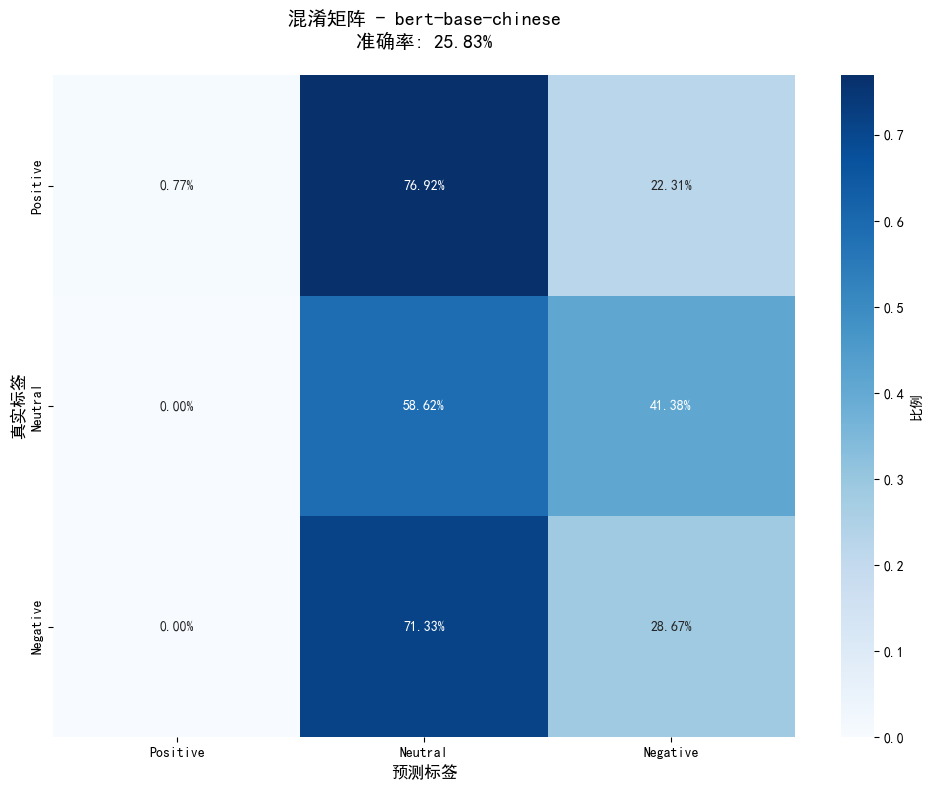


混淆矩阵(实际数量):


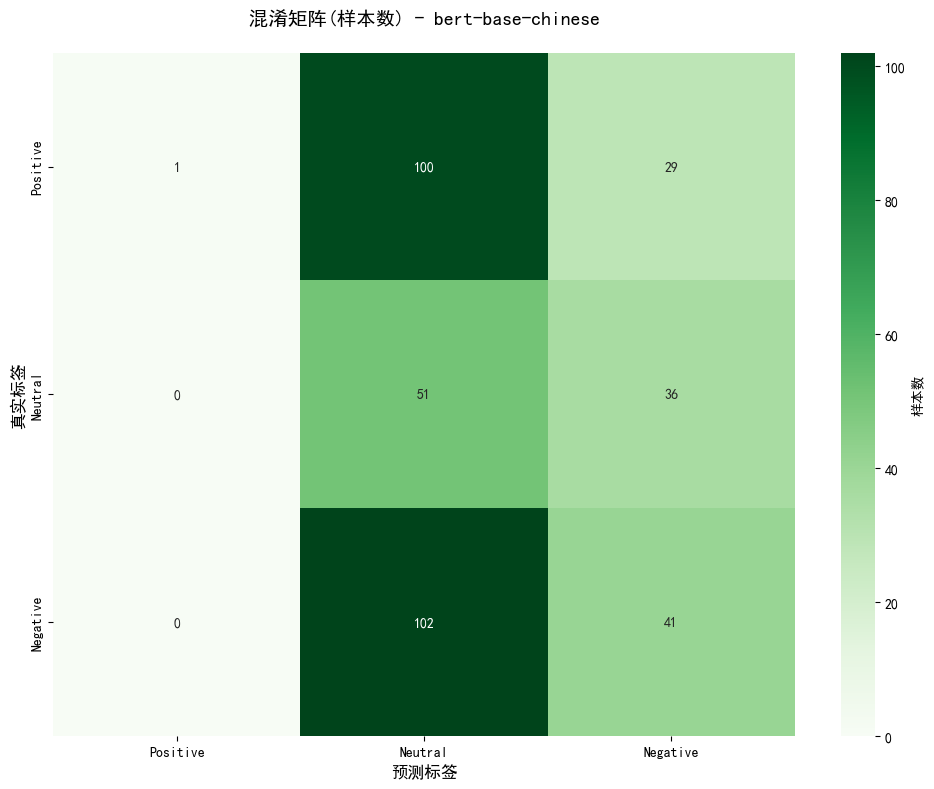

In [13]:
if len(all_data) > 0:
    plt.figure(figsize=(10, 8))
    
    # 归一化混淆矩阵(按行归一化,显示百分比)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # 绘制热力图
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt='.2%',
        cmap='Blues',
        xticklabels=['Positive', 'Neutral', 'Negative'],
        yticklabels=['Positive', 'Neutral', 'Negative'],
        cbar_kws={'label': '比例'}
    )
    
    plt.title(f'混淆矩阵 - {MODEL_NAME}\n准确率: {accuracy:.2%}', fontsize=14, pad=20)
    plt.ylabel('真实标签', fontsize=12)
    plt.xlabel('预测标签', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # 显示实际数量
    print("\n混淆矩阵(实际数量):")
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=['Positive', 'Neutral', 'Negative'],
        yticklabels=['Positive', 'Neutral', 'Negative'],
        cbar_kws={'label': '样本数'}
    )
    plt.title(f'混淆矩阵(样本数) - {MODEL_NAME}', fontsize=14, pad=20)
    plt.ylabel('真实标签', fontsize=12)
    plt.xlabel('预测标签', fontsize=12)
    plt.tight_layout()
    plt.show()

## 10. 可视化 - 各平台准确率对比

C:\Users\gzs27\AppData\Local\Temp\ipykernel_18808\1269374498.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  platform_accuracy = df_all.groupby('platform').apply(


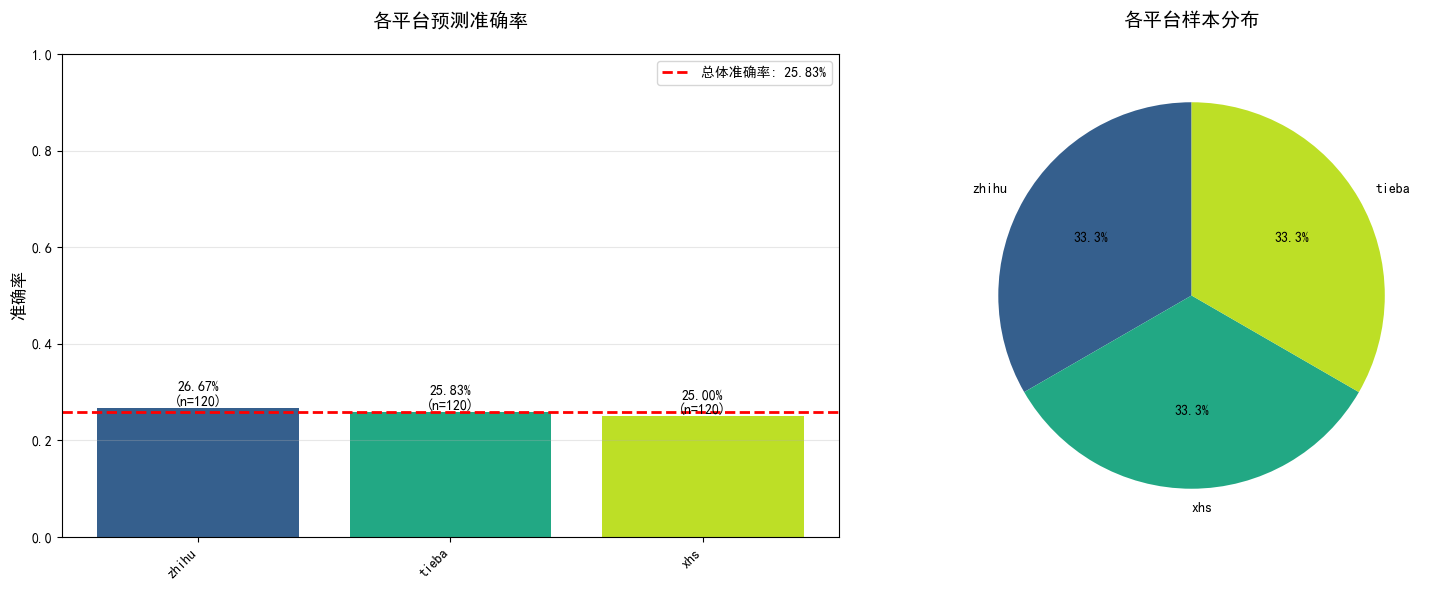


各平台详细统计:


,平台,准确率,样本数
0,zhihu,26.67%,120
1,tieba,25.83%,120
2,xhs,25.00%,120


In [14]:
if len(all_data) > 0:
    # 计算各平台准确率
    platform_accuracy = df_all.groupby('platform').apply(
        lambda x: (x['manual_sentiment_label'] == x['predicted_label']).mean()
    ).sort_values(ascending=False)
    
    # 计算各平台样本数
    platform_counts = df_all['platform'].value_counts()
    
    # 绘图
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 准确率柱状图
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(platform_accuracy)))
    bars = ax1.bar(range(len(platform_accuracy)), platform_accuracy.values, color=colors)
    ax1.set_xticks(range(len(platform_accuracy)))
    ax1.set_xticklabels(platform_accuracy.index, rotation=45, ha='right')
    ax1.set_ylabel('准确率', fontsize=12)
    ax1.set_title('各平台预测准确率', fontsize=14, pad=20)
    ax1.set_ylim([0, 1])
    ax1.axhline(y=accuracy, color='r', linestyle='--', linewidth=2, label=f'总体准确率: {accuracy:.2%}')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # 在柱状图上显示数值
    for i, (bar, val) in enumerate(zip(bars, platform_accuracy.values)):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2%}\n(n={platform_counts[platform_accuracy.index[i]]})',
                ha='center', va='bottom', fontsize=10)
    
    # 样本数饼图
    ax2.pie(platform_counts.values, labels=platform_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors)
    ax2.set_title('各平台样本分布', fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # 详细统计表
    print("\n各平台详细统计:")
    platform_stats = pd.DataFrame({
        '平台': platform_accuracy.index,
        '准确率': [f'{x:.2%}' for x in platform_accuracy.values],
        '样本数': [platform_counts[p] for p in platform_accuracy.index]
    })
    display(platform_stats)

## 11. 可视化 - 预测置信度分布

In [ ]:
if len(all_data) > 0:
    # 分析正确和错误预测的置信度差异
    df_all['is_correct'] = df_all['manual_sentiment_label'] == df_all['predicted_label']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. 整体置信度分布(正确 vs 错误)
    ax = axes[0, 0]
    correct_conf = df_all[df_all['is_correct']]['predicted_confidence']
    wrong_conf = df_all[~df_all['is_correct']]['predicted_confidence']
    
    ax.hist([correct_conf, wrong_conf], bins=20, label=['正确预测', '错误预测'], 
            color=['green', 'red'], alpha=0.6, edgecolor='black')
    ax.set_xlabel('预测置信度', fontsize=11)
    ax.set_ylabel('样本数', fontsize=11)
    ax.set_title('预测置信度分布对比', fontsize=13)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # 2. 各类别置信度箱线图
    ax = axes[0, 1]
    data_by_label = [
        df_all[df_all['predicted_label'] == 'positive']['predicted_confidence'],
        df_all[df_all['predicted_label'] == 'neutral']['predicted_confidence'],
        df_all[df_all['predicted_label'] == 'negative']['predicted_confidence']
    ]
    bp = ax.boxplot(data_by_label, labels=['Positive', 'Neutral', 'Negative'],
                    patch_artist=True)
    for patch, color in zip(bp['boxes'], ['lightgreen', 'lightblue', 'lightcoral']):
        patch.set_facecolor(color)
    ax.set_ylabel('预测置信度', fontsize=11)
    ax.set_title('各类别预测置信度箱线图', fontsize=13)
    ax.grid(axis='y', alpha=0.3)
    
    # 3. 置信度与准确率关系
    ax = axes[1, 0]
    confidence_bins = np.arange(0, 1.1, 0.1)
    df_all['conf_bin'] = pd.cut(df_all['predicted_confidence'], bins=confidence_bins)
    
    accuracy_by_conf = df_all.groupby('conf_bin', observed=True)['is_correct'].agg(['mean', 'count'])
    
    x_pos = np.arange(len(accuracy_by_conf))
    bars = ax.bar(x_pos, accuracy_by_conf['mean'], color='steelblue', alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'{i/10:.1f}' for i in range(len(accuracy_by_conf))], rotation=45)
    ax.set_xlabel('置信度区间', fontsize=11)
    ax.set_ylabel('准确率', fontsize=11)
    ax.set_title('不同置信度区间的预测准确率', fontsize=13)
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    # 在柱上显示样本数
    for i, (bar, count) in enumerate(zip(bars, accuracy_by_conf['count'])):
        if count > 0:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'n={int(count)}', ha='center', va='bottom', fontsize=8)
    
    # 4. 累积准确率曲线
    ax = axes[1, 1]
    df_sorted = df_all.sort_values('predicted_confidence', ascending=False).reset_index(drop=True)
    cumulative_accuracy = df_sorted['is_correct'].expanding().mean()
    coverage = np.arange(1, len(df_sorted) + 1) / len(df_sorted)
    
    ax.plot(coverage * 100, cumulative_accuracy, linewidth=2, color='darkblue')
    ax.axhline(y=accuracy, color='r', linestyle='--', linewidth=2, 
               label=f'总体准确率: {accuracy:.2%}')
    ax.set_xlabel('样本覆盖率 (%)', fontsize=11)
    ax.set_ylabel('累积准确率', fontsize=11)
    ax.set_title('按置信度排序的累积准确率', fontsize=13)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()
    
    # 统计信息
    print(f"\n置信度统计:")
    print(f"正确预测平均置信度: {correct_conf.mean():.4f}")
    print(f"错误预测平均置信度: {wrong_conf.mean():.4f}")
    print(f"置信度差异: {correct_conf.mean() - wrong_conf.mean():.4f}")

## 12. 保存预测结果到数据库

In [15]:
async def save_predictions_to_db():
    """保存预测结果到数据库"""
    conn = await get_mysql_connection()
    try:
        async with conn.cursor() as cursor:
            # 创建结果表(如果不存在)
            await cursor.execute("""
                CREATE TABLE IF NOT EXISTS transformer_predictions (
                    id BIGINT AUTO_INCREMENT PRIMARY KEY,
                    data_type VARCHAR(20) NOT NULL COMMENT '数据类型: note/comment',
                    data_id BIGINT NOT NULL COMMENT '原始数据ID',
                    platform VARCHAR(50) COMMENT '平台',
                    model_name VARCHAR(200) NOT NULL COMMENT '模型名称',
                    predicted_label VARCHAR(20) NOT NULL COMMENT '预测标签',
                    predicted_score FLOAT COMMENT '预测分数',
                    predicted_confidence FLOAT COMMENT '预测置信度',
                    manual_label VARCHAR(20) COMMENT '人工标注',
                    is_correct BOOLEAN COMMENT '是否正确',
                    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
                    INDEX idx_data (data_type, data_id),
                    INDEX idx_model (model_name),
                    INDEX idx_created (created_at)
                ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4 COMMENT='Transformer模型预测结果'
            """)
            print("✓ 结果表创建/验证完成")
            
            # 保存笔记预测结果
            if len(df_notes) > 0:
                note_records = []
                for _, row in df_notes.iterrows():
                    note_records.append((
                        'note',
                        int(row['id']),
                        row['platform'],
                        MODEL_NAME,
                        row['predicted_label'],
                        float(row['predicted_score']),
                        float(row['predicted_confidence']),
                        row['manual_sentiment_label'],
                        bool(row['is_correct'])
                    ))
                
                await cursor.executemany("""
                    INSERT INTO transformer_predictions 
                    (data_type, data_id, platform, model_name, predicted_label, 
                     predicted_score, predicted_confidence, manual_label, is_correct)
                    VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
                """, note_records)
                print(f"✓ 已保存 {len(note_records)} 条笔记预测结果")
            
            # 保存评论预测结果
            if len(df_comments) > 0:
                comment_records = []
                for _, row in df_comments.iterrows():
                    comment_records.append((
                        'comment',
                        int(row['id']),
                        row['platform'],
                        MODEL_NAME,
                        row['predicted_label'],
                        float(row['predicted_score']),
                        float(row['predicted_confidence']),
                        row['manual_sentiment_label'],
                        bool(row['is_correct'])
                    ))
                
                await cursor.executemany("""
                    INSERT INTO transformer_predictions 
                    (data_type, data_id, platform, model_name, predicted_label, 
                     predicted_score, predicted_confidence, manual_label, is_correct)
                    VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
                """, comment_records)
                print(f"✓ 已保存 {len(comment_records)} 条评论预测结果")
            
            await conn.commit()
            print("\n✓ 所有结果已保存到数据库")
            
    except Exception as e:
        print(f"❌ 保存失败: {e}")
        await conn.rollback()
    finally:
        conn.close()

# 执行保存
if len(all_data) > 0:
    await save_predictions_to_db()
else:
    print("没有数据需要保存")

✓ 结果表创建/验证完成
✓ 已保存 60 条笔记预测结果
✓ 已保存 300 条评论预测结果

✓ 所有结果已保存到数据库


## 13. 查询并验证保存的结果

In [16]:
async def query_saved_results():
    """查询保存的预测结果"""
    conn = await get_mysql_connection()
    try:
        async with conn.cursor(aiomysql.DictCursor) as cursor:
            # 查询最近的预测记录
            await cursor.execute("""
                SELECT 
                    data_type,
                    COUNT(*) as count,
                    AVG(is_correct) as accuracy,
                    MIN(created_at) as first_record,
                    MAX(created_at) as last_record
                FROM transformer_predictions
                WHERE model_name = %s
                GROUP BY data_type
            """, (MODEL_NAME,))
            
            results = await cursor.fetchall()
            
            if results:
                print("=" * 80)
                print("数据库中的预测结果统计".center(80))
                print("=" * 80)
                
                summary_df = pd.DataFrame(results)
                summary_df['accuracy'] = summary_df['accuracy'].apply(lambda x: f'{x:.2%}')
                display(summary_df)
                
                # 查询最近10条记录示例
                await cursor.execute("""
                    SELECT 
                        data_type, data_id, platform, predicted_label, 
                        predicted_confidence, manual_label, is_correct, created_at
                    FROM transformer_predictions
                    WHERE model_name = %s
                    ORDER BY created_at DESC
                    LIMIT 10
                """, (MODEL_NAME,))
                
                recent_records = await cursor.fetchall()
                print("\n最近10条预测记录:")
                display(pd.DataFrame(recent_records))
            else:
                print("数据库中暂无该模型的预测结果")
                
    finally:
        conn.close()

# 执行查询
if len(all_data) > 0:
    await query_saved_results()
else:
    print("没有数据可查询")

                                  数据库中的预测结果统计                                   


,data_type,count,accuracy,first_record,last_record
0,comment,300,29.00%,2025-12-08 16:54:10,2025-12-08 16:54:10
1,note,60,10.00%,2025-12-08 16:54:10,2025-12-08 16:54:10



最近10条预测记录:


,data_type,data_id,platform,predicted_label,predicted_confidence,manual_label,is_correct,created_at
0,comment,300,tieba,neutral,0.456991,negative,0,2025-12-08 16:54:10
1,comment,299,tieba,neutral,0.548381,negative,0,2025-12-08 16:54:10
2,comment,298,tieba,negative,0.493427,neutral,0,2025-12-08 16:54:10
3,comment,297,tieba,negative,0.426966,neutral,0,2025-12-08 16:54:10
4,comment,296,tieba,negative,0.402345,positive,0,2025-12-08 16:54:10
5,comment,295,tieba,negative,0.442538,positive,0,2025-12-08 16:54:10
6,comment,294,tieba,neutral,0.436280,negative,0,2025-12-08 16:54:10
7,comment,293,tieba,neutral,0.440370,neutral,1,2025-12-08 16:54:10
8,comment,292,tieba,neutral,0.440867,neutral,1,2025-12-08 16:54:10
9,comment,291,tieba,neutral,0.439020,negative,0,2025-12-08 16:54:10


## 14. 生成评估报告总结

In [17]:
if len(all_data) > 0:
    print("=" * 80)
    print("Transformer模型情感分析评估报告".center(80))
    print("=" * 80)
    
    print(f"\n【模型信息】")
    print(f"  模型名称: {MODEL_NAME}")
    print(f"  设备: {DEVICE}")
    print(f"  模型参数量: {total_params:,}")
    print(f"  批处理大小: {BATCH_SIZE}")
    print(f"  最大序列长度: {MAX_LENGTH}")
    
    print(f"\n【数据统计】")
    print(f"  笔记数据: {len(df_notes)} 条")
    print(f"  评论数据: {len(df_comments)} 条")
    print(f"  总计: {len(df_all)} 条")
    
    print(f"\n【整体性能指标】")
    print(f"  准确率 (Accuracy): {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  精确率 (Precision): {precision:.4f}")
    print(f"  召回率 (Recall): {recall:.4f}")
    print(f"  F1值 (F1-Score): {f1:.4f}")
    
    print(f"\n【各类别性能】")
    for i, label in enumerate(['positive', 'neutral', 'negative']):
        print(f"  {label.capitalize():10s}: P={precision_per_class[i]:.3f}, "
              f"R={recall_per_class[i]:.3f}, F1={f1_per_class[i]:.3f}, "
              f"支持数={support_per_class[i]}")
    
    print(f"\n【平台表现】")
    for platform in platform_accuracy.index:
        acc = platform_accuracy[platform]
        count = platform_counts[platform]
        print(f"  {platform:15s}: {acc:.2%} (n={count})")
    
    print(f"\n【置信度分析】")
    if len(correct_conf) > 0:
        print(f"  正确预测平均置信度: {correct_conf.mean():.4f}")
    if len(wrong_conf) > 0:
        print(f"  错误预测平均置信度: {wrong_conf.mean():.4f}")
        if len(correct_conf) > 0:
            print(f"  置信度差异: {correct_conf.mean() - wrong_conf.mean():.4f}")
    
    print(f"\n【评估时间】")
    print(f"  评估日期: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    
    print("\n" + "=" * 80)
    print("评估完成!".center(80))
    print("=" * 80)
    
    # 生成建议
    print("\n【模型优化建议】")
    if accuracy < 0.7:
        print("  ⚠️ 准确率较低,建议:")
        print("     - 尝试使用更强大的模型(如 hfl/chinese-roberta-wwm-ext)")
        print("     - 增加训练数据量")
        print("     - 检查数据质量和标注一致性")
    elif accuracy < 0.85:
        print("  ℹ️ 准确率中等,建议:")
        print("     - 考虑模型微调(fine-tuning)")
        print("     - 分析错误样本,优化数据预处理")
    else:
        print("  ✓ 准确率良好!")
    
    if len(wrong_conf) > 0 and wrong_conf.mean() > 0.7:
        print("  ⚠️ 错误预测的置信度较高,建议:")
        print("     - 人工审查高置信度但错误的样本")
        print("     - 可能存在标注错误或模型偏见")
    
    if platform_accuracy.std() > 0.15:
        print("  ⚠️ 不同平台表现差异较大,建议:")
        print("     - 针对表现较差的平台增加训练数据")
        print("     - 考虑针对不同平台单独训练模型")
else:
    print("没有数据用于生成报告")

                             Transformer模型情感分析评估报告                              

【模型信息】
  模型名称: bert-base-chinese
  设备: cuda
  模型参数量: 102,269,955
  批处理大小: 16
  最大序列长度: 512

【数据统计】
  笔记数据: 60 条
  评论数据: 300 条
  总计: 360 条

【整体性能指标】
  准确率 (Accuracy): 0.2583 (25.83%)
  精确率 (Precision): 0.5295
  召回率 (Recall): 0.2935
  F1值 (F1-Score): 0.2149

【各类别性能】
  Positive  : P=1.000, R=0.008, F1=0.015, 支持数=130
  Neutral   : P=0.202, R=0.586, F1=0.300, 支持数=87
  Negative  : P=0.387, R=0.287, F1=0.329, 支持数=143

【平台表现】
  zhihu          : 26.67% (n=120)
  tieba          : 25.83% (n=120)
  xhs            : 25.00% (n=120)

【置信度分析】


NameError: name 'correct_conf' is not defined